In [1]:
# Environment setup
import sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "config").is_dir() and (p / "src").is_dir():
            return p
    raise RuntimeError(f"Could not find project root from {start}")

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/mac/Studying/OTTO/scenario_generator


In [2]:
# Load fault scenarios
import pandas as pd
from pathlib import Path

DATA_DIR = PROJECT_ROOT / "data" / "suv_b"

torque_drop = {
    "signals": pd.read_csv(DATA_DIR / "highway_cruise_with_intermittent_torque_drops.signals.csv"),
    "faults":  pd.read_csv(DATA_DIR / "highway_cruise_with_intermittent_torque_drops.faults.csv"),
    "labels":  pd.read_csv(DATA_DIR / "highway_cruise_with_intermittent_torque_drops.labels.csv"),
    "name":    "Highway Cruise with Intermittent Torque Drops",
}

crank_freeze = {
    "signals": pd.read_csv(DATA_DIR / "highway_cruise_with_crank_sensor_freeze.signals.csv"),
    "faults":  pd.read_csv(DATA_DIR / "highway_cruise_with_crank_sensor_freeze.faults.csv"),
    "labels":  pd.read_csv(DATA_DIR / "highway_cruise_with_crank_sensor_freeze.labels.csv"),
    "name":    "Highway Cruise with Crank Sensor Freeze",
}

for name, data in [("torque_drop", torque_drop), ("crank_freeze", crank_freeze)]:
    print(f"{name}:")
    print(f"  signals: {data['signals'].shape}")
    print(f"  faults:  {data['faults'].shape}")
    print(f"  labels:  {data['labels'].shape}")
    print()

torque_drop:
  signals: (9000, 11)
  faults:  (1, 11)
  labels:  (15300, 9)

crank_freeze:
  signals: (9000, 11)
  faults:  (1, 11)
  labels:  (15300, 9)



In [3]:
# Torque drop fault summary
print("Fault declaration:")
print(torque_drop["faults"].to_string(index=False))
print()
sig = torque_drop["signals"]
print(f"Signal window: t = {sig['time_s'].min():.1f} – {sig['time_s'].max():.1f} s")
print(f"RPM range: {sig['engine_rpm'].min():.1f} – {sig['engine_rpm'].max():.1f}")
print()
n_faulty = (torque_drop["labels"]["is_fault"] == 1).sum()
print(f"Faulty frames: {n_faulty} / {len(torque_drop['labels'])} "
      f"({100 * n_faulty / len(torque_drop['labels']):.2f}%)")

Fault declaration:
     fault_id             fault_type  onset_s  end_s  severity  severity_start  severity_end progression physical_category observable_effect          affected_signals
misfire_train crankshaft_torque_drop     28.0   65.0       0.7             0.0           0.0    constant        mechanical           dropout crank_position;engine_rpm

Signal window: t = 0.0 – 90.0 s
RPM range: 800.0 – 4085.6

Faulty frames: 6290 / 15300 (41.11%)


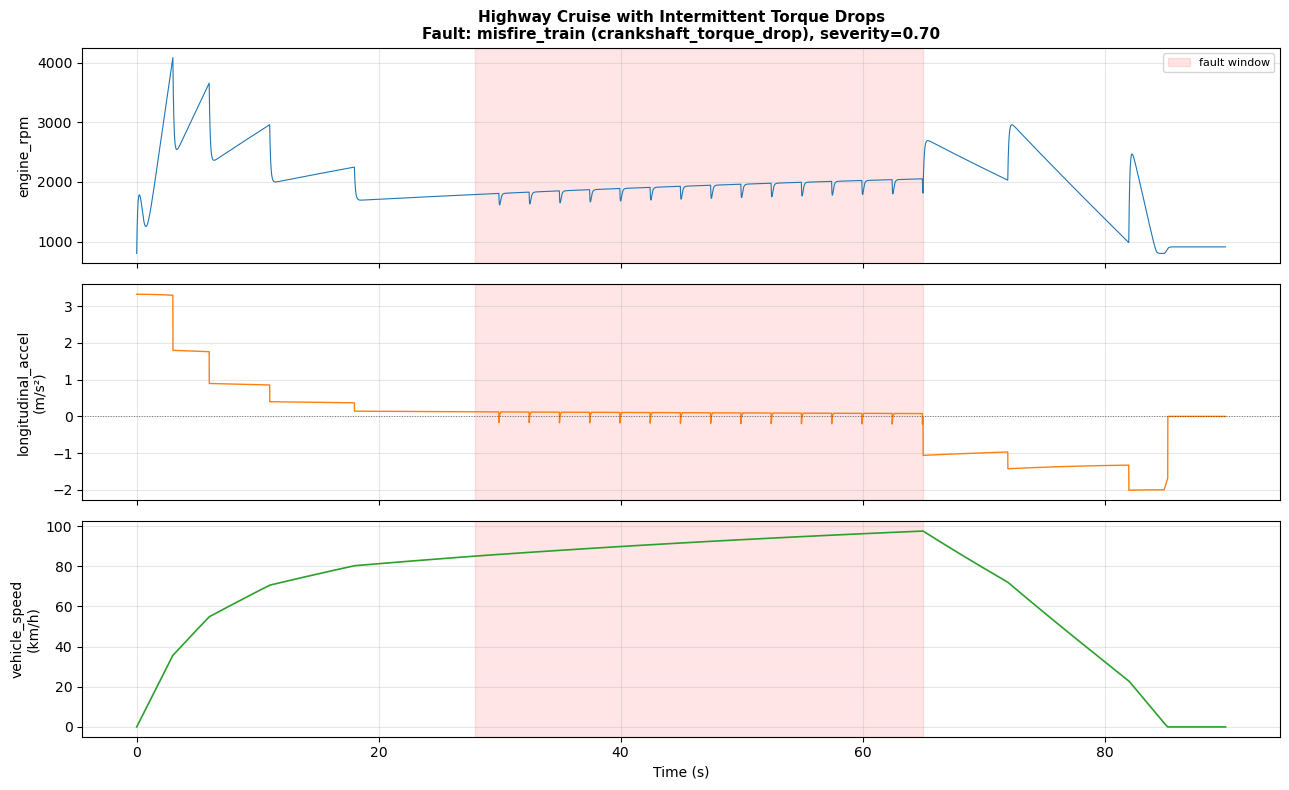

In [4]:
# Torque drops: engine_rpm over the full scenario
import matplotlib.pyplot as plt

sig = torque_drop["signals"]
fault = torque_drop["faults"].iloc[0]
onset, end = fault["onset_s"], fault["end_s"]

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

# RPM
axes[0].plot(sig["time_s"], sig["engine_rpm"], linewidth=0.8, color="tab:blue")
axes[0].axvspan(onset, end, alpha=0.10, color="red", label="fault window")
axes[0].set_ylabel("engine_rpm")
axes[0].set_title(
    f"{torque_drop['name']}\n"
    f"Fault: {fault['fault_id']} ({fault['fault_type']}), "
    f"severity={fault['severity']:.2f}",
    fontsize=11, fontweight="bold"
)
axes[0].grid(alpha=0.3)
axes[0].legend(loc="upper right", fontsize=8)

# Longitudinal acceleration
axes[1].plot(sig["time_s"], sig["longitudinal_acceleration"], linewidth=1.0, color="tab:orange")
axes[1].axvspan(onset, end, alpha=0.10, color="red")
axes[1].axhline(0, color="black", linestyle=":", linewidth=0.7, alpha=0.5)
axes[1].set_ylabel("longitudinal_accel\n(m/s²)")
axes[1].grid(alpha=0.3)

# Vehicle speed
axes[2].plot(sig["time_s"], sig["vehicle_speed"], linewidth=1.2, color="tab:green")
axes[2].axvspan(onset, end, alpha=0.10, color="red")
axes[2].set_ylabel("vehicle_speed\n(km/h)")
axes[2].set_xlabel("Time (s)")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

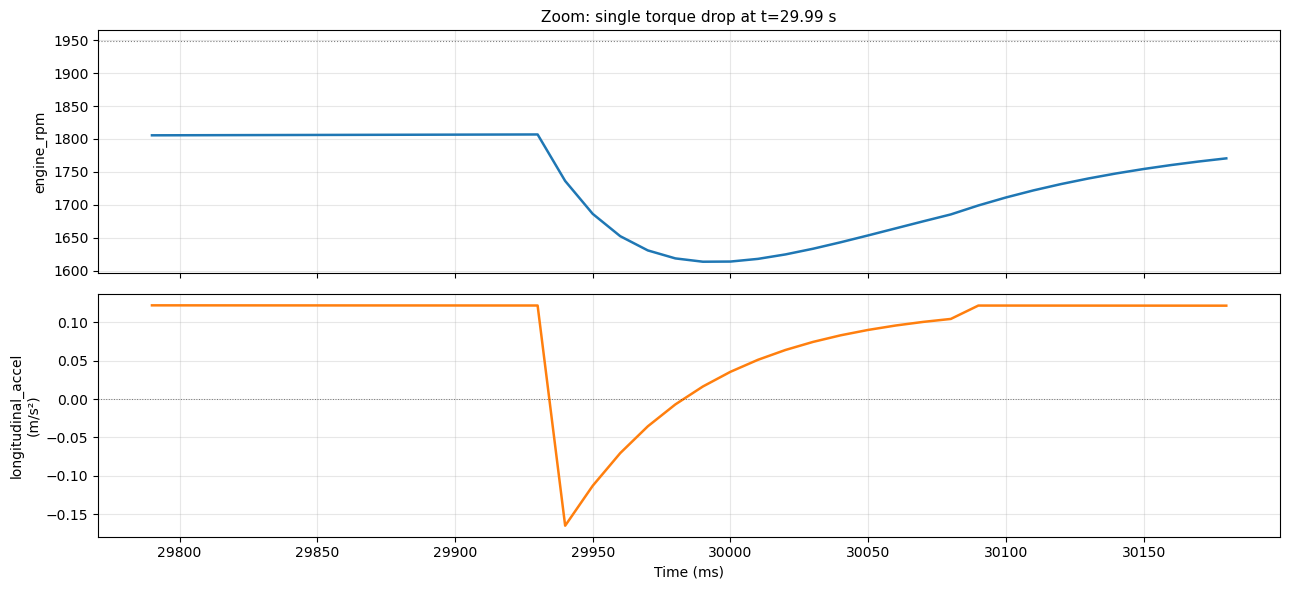

Baseline RPM (median outside fault): 2064.9
Deepest RPM during fault:            1613.4
RPM dip magnitude:                   451.5


In [5]:
# Zoom into one torque drop
import numpy as np

sig = torque_drop["signals"]
fault = torque_drop["faults"].iloc[0]

# Find the deepest RPM dip within the fault window
mask = (sig["time_s"] >= fault["onset_s"]) & (sig["time_s"] <= fault["end_s"])
window = sig[mask]
dip_idx = window["engine_rpm"].idxmin()
dip_time = sig.loc[dip_idx, "time_s"]

# Show a 400 ms window centered on the dip
zoom_start = dip_time - 0.2
zoom_end = dip_time + 0.2
zoom_mask = (sig["time_s"] >= zoom_start) & (sig["time_s"] <= zoom_end)
sub = sig[zoom_mask]

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(sub["time_s"] * 1000, sub["engine_rpm"], linewidth=1.8, color="tab:blue")
axes[0].axhline(sig["engine_rpm"].median(), color="gray", linestyle=":", linewidth=0.8)
axes[0].set_ylabel("engine_rpm")
axes[0].set_title(f"Zoom: single torque drop at t={dip_time:.2f} s", fontsize=11)
axes[0].grid(alpha=0.3)

axes[1].plot(sub["time_s"] * 1000, sub["longitudinal_acceleration"], linewidth=1.8, color="tab:orange")
axes[1].axhline(0, color="black", linestyle=":", linewidth=0.7, alpha=0.5)
axes[1].set_ylabel("longitudinal_accel\n(m/s²)")
axes[1].set_xlabel("Time (ms)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Quantify the dip
clean_median = sig.loc[~mask, "engine_rpm"].median()
dip_min = sig.loc[mask, "engine_rpm"].min()
print(f"Baseline RPM (median outside fault): {clean_median:.1f}")
print(f"Deepest RPM during fault:            {dip_min:.1f}")
print(f"RPM dip magnitude:                   {clean_median - dip_min:.1f}")

In [6]:
# Crank sensor fault summary
print("Fault declaration:")
print(crank_freeze["faults"].to_string(index=False))
print()
sig = crank_freeze["signals"]
n_faulty = (crank_freeze["labels"]["is_fault"] == 1).sum()
print(f"Faulty frames: {n_faulty} / {len(crank_freeze['labels'])} "
      f"({100 * n_faulty / len(crank_freeze['labels']):.2f}%)")

Fault declaration:
     fault_id           fault_type  onset_s  end_s  severity  severity_start  severity_end progression physical_category observable_effect          affected_signals
sensor_freeze crank_sensor_failure     38.0   65.0  0.333333             0.0           0.0    constant            sensor            freeze crank_position;engine_rpm

Faulty frames: 4590 / 15300 (30.00%)


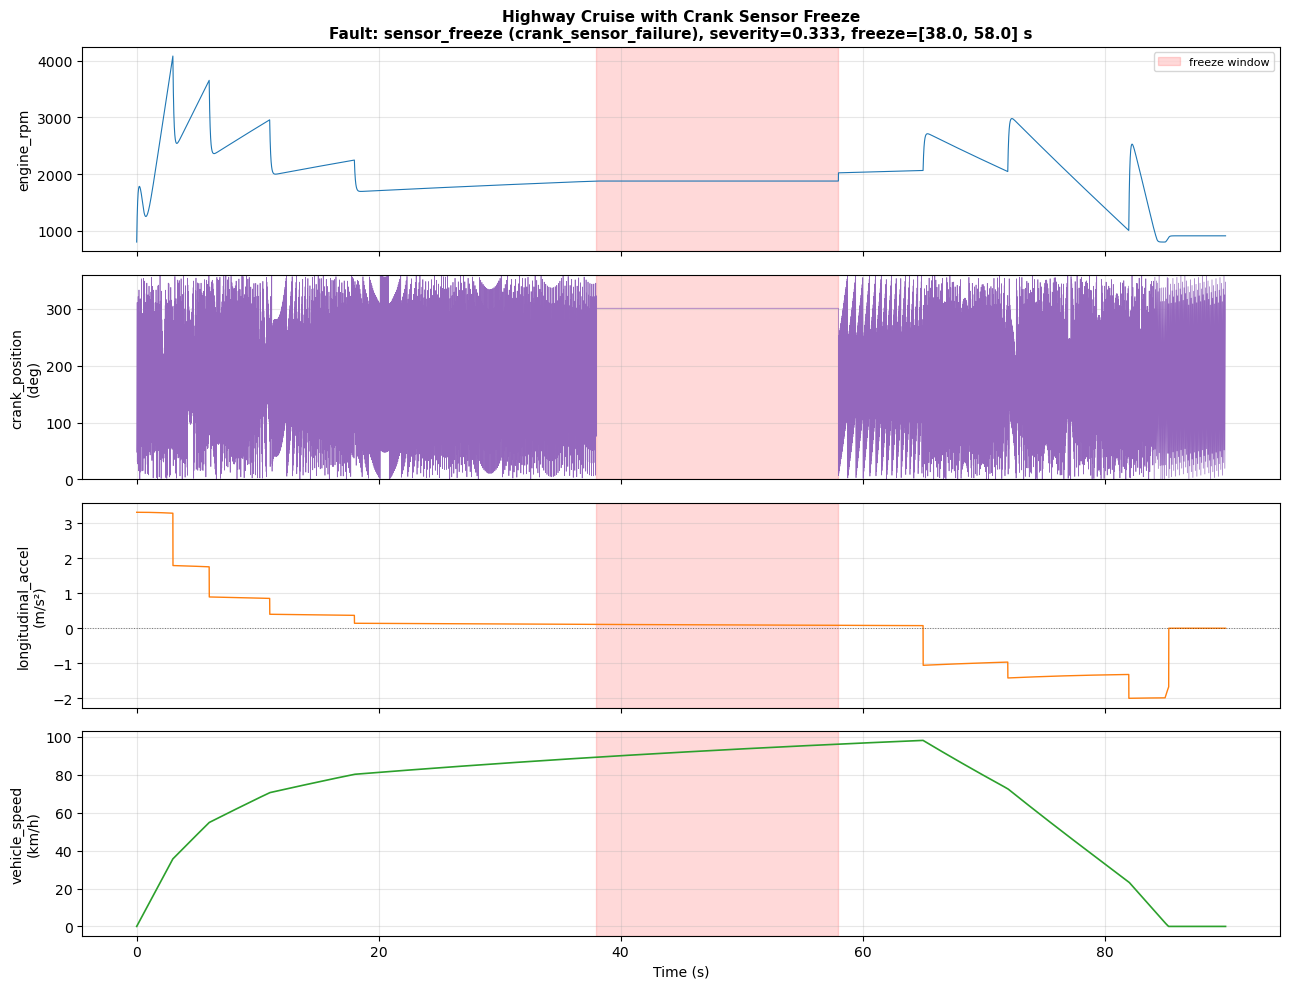

In [13]:
# Cell 6 — Crank sensor freeze: engine_rpm and crank_position
from src.config_loader import ConfigLoader
from src.signal_generator import Scenario

# Determine the actual freeze end from the scenario
loader = ConfigLoader(PROJECT_ROOT / "config")
scenario = Scenario.from_yaml(
    PROJECT_ROOT / "config" / "scenarios" / "highway_cruise_crank_sensor_freeze.yaml",
    fault_registry=loader.load_fault_types(),
)
fault = scenario.resolved_faults[0]
onset = fault.onset_s
freeze_end = onset + fault.params["freeze_duration_s"]

# Shade only the actual freeze window
sig = crank_freeze["signals"]

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

# engine_rpm
axes[0].plot(sig["time_s"], sig["engine_rpm"], linewidth=0.8, color="tab:blue")
axes[0].axvspan(onset, freeze_end, alpha=0.15, color="red", label="freeze window")
axes[0].set_ylabel("engine_rpm")
axes[0].set_title(
    f"{crank_freeze['name']}\n"
    f"Fault: {fault.id} ({fault.type}), "
    f"severity={crank_freeze['faults'].iloc[0]['severity']:.3f}, "
    f"freeze=[{onset}, {freeze_end}] s",
    fontsize=11, fontweight="bold"
)
axes[0].grid(alpha=0.3)
axes[0].legend(loc="upper right", fontsize=8)

# crank_position
axes[1].plot(sig["time_s"], sig["crank_position"], linewidth=0.5, color="tab:purple")
axes[1].axvspan(onset, freeze_end, alpha=0.15, color="red")
axes[1].set_ylabel("crank_position\n(deg)")
axes[1].set_ylim(0, 360)
axes[1].grid(alpha=0.3)

# longitudinal_acceleration — unaffected
axes[2].plot(sig["time_s"], sig["longitudinal_acceleration"], linewidth=1.0, color="tab:orange")
axes[2].axvspan(onset, freeze_end, alpha=0.15, color="red")
axes[2].axhline(0, color="black", linestyle=":", linewidth=0.7, alpha=0.5)
axes[2].set_ylabel("longitudinal_accel\n(m/s²)")
axes[2].grid(alpha=0.3)

# vehicle_speed — unaffected
axes[3].plot(sig["time_s"], sig["vehicle_speed"], linewidth=1.2, color="tab:green")
axes[3].axvspan(onset, freeze_end, alpha=0.15, color="red")
axes[3].set_ylabel("vehicle_speed\n(km/h)")
axes[3].set_xlabel("Time (s)")
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Cross-check: engine is fine, only the sensor is broken
sig = crank_freeze["signals"]
fault = crank_freeze["faults"].iloc[0]
onset, end = fault["onset_s"], fault["end_s"]

# Compare standard deviations in the freeze window for:
#   - engine_rpm (should be 0 — frozen)
#   - crank_position (should be 0 — frozen)
#   - throttle_position (should be normal)
#   - longitudinal_acceleration (should be normal)
#   - vehicle_speed (should be normal)

mask = (sig["time_s"] >= onset) & (sig["time_s"] < end)
window = sig[mask]

print(f"Freeze window: t = [{onset:.1f}, {end:.1f}] s  ({end - onset:.1f} s)")
print()
print(f"{'signal':30s}  {'std in window':>15s}  {'expected':>15s}")
print("-" * 70)
expected = {
    "engine_rpm": "≈ 0 (frozen)",
    "crank_position": "≈ 0 (frozen)",
    "throttle_position": "normal",
    "longitudinal_acceleration": "normal",
    "vehicle_speed": "normal",
    "brake_pressure": "normal",
    "coolant_temperature": "normal",
}
for s in expected:
    std = window[s].std()
    print(f"{s:30s}  {std:>15.4f}  {expected[s]:>15s}")

Freeze window: t = [38.0, 65.0] s  (27.0 s)

signal                            std in window         expected
----------------------------------------------------------------------
engine_rpm                              73.1165     ≈ 0 (frozen)
crank_position                          75.1364     ≈ 0 (frozen)
throttle_position                        0.0000           normal
longitudinal_acceleration                0.0101           normal
vehicle_speed                            2.5596           normal
brake_pressure                           0.0000           normal
coolant_temperature                      1.5325           normal


Evolution: Intermittent Torque Drops Over 90 Days

recording_id  day  severity progression  n_frames  n_signal_rows fault_id             fault_type
      day_01    1      0.00       pulse     15300           9000   day_01 crankshaft_torque_drop
      day_15   15      0.30       pulse     15300           9000   day_15 crankshaft_torque_drop
      day_30   30      0.45       pulse     15300           9000   day_30 crankshaft_torque_drop
      day_60   60      0.60       pulse     15300           9000   day_60 crankshaft_torque_drop
      day_90   90      0.75       pulse     15300           9000   day_90 crankshaft_torque_drop
      day_95   95      0.20       pulse     15300           9000   day_95 crankshaft_torque_drop



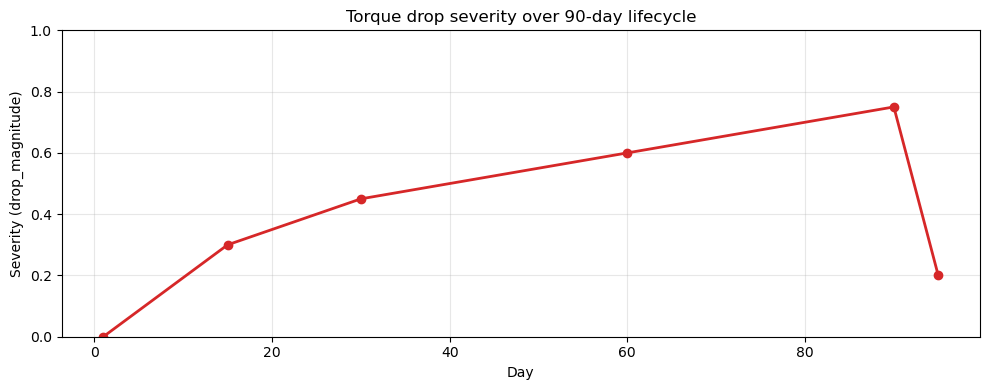

In [9]:
# Torque drops evolution
import json

evo_dir = (PROJECT_ROOT / "data" / "suv_b" / "evolutions"
           / "intermittent_torque_drops_over_90_days")

timeline = pd.read_csv(evo_dir / "timeline.csv")
with open(evo_dir / "metadata.json") as f:
    meta = json.load(f)

print("Evolution:", meta["evolution_name"])
print()
print(timeline.to_string(index=False))
print()

# Plot the severity trajectory
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(timeline["day"], timeline["severity"], marker="o", linewidth=2, color="tab:red")
ax.set_xlabel("Day")
ax.set_ylabel("Severity (drop_magnitude)")
ax.set_title("Torque drop severity over 90-day lifecycle")
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Evolution: Crank Sensor Freeze Over 90 Days

recording_id  day  severity progression  n_frames  n_signal_rows fault_id           fault_type
      day_01    1      0.00    constant     15300           9000   day_01 crank_sensor_failure
      day_15   15      0.10    constant     15300           9000   day_15 crank_sensor_failure
      day_30   30      0.25    constant     15300           9000   day_30 crank_sensor_failure
      day_60   60      0.50    constant     15300           9000   day_60 crank_sensor_failure
      day_90   90      0.85    constant     15300           9000   day_90 crank_sensor_failure
      day_95   95      0.05    constant     15300           9000   day_95 crank_sensor_failure



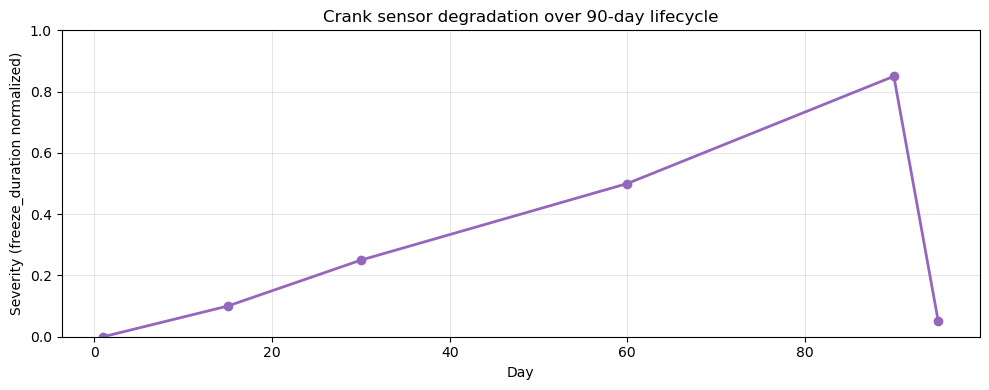

In [10]:
# Crank sensor freeze evolution
evo_dir = (PROJECT_ROOT / "data" / "suv_b" / "evolutions"
           / "crank_sensor_freeze_over_90_days")

timeline = pd.read_csv(evo_dir / "timeline.csv")
with open(evo_dir / "metadata.json") as f:
    meta = json.load(f)

print("Evolution:", meta["evolution_name"])
print()
print(timeline.to_string(index=False))
print()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(timeline["day"], timeline["severity"], marker="o", linewidth=2, color="tab:purple")
ax.set_xlabel("Day")
ax.set_ylabel("Severity (freeze_duration normalized)")
ax.set_title("Crank sensor degradation over 90-day lifecycle")
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

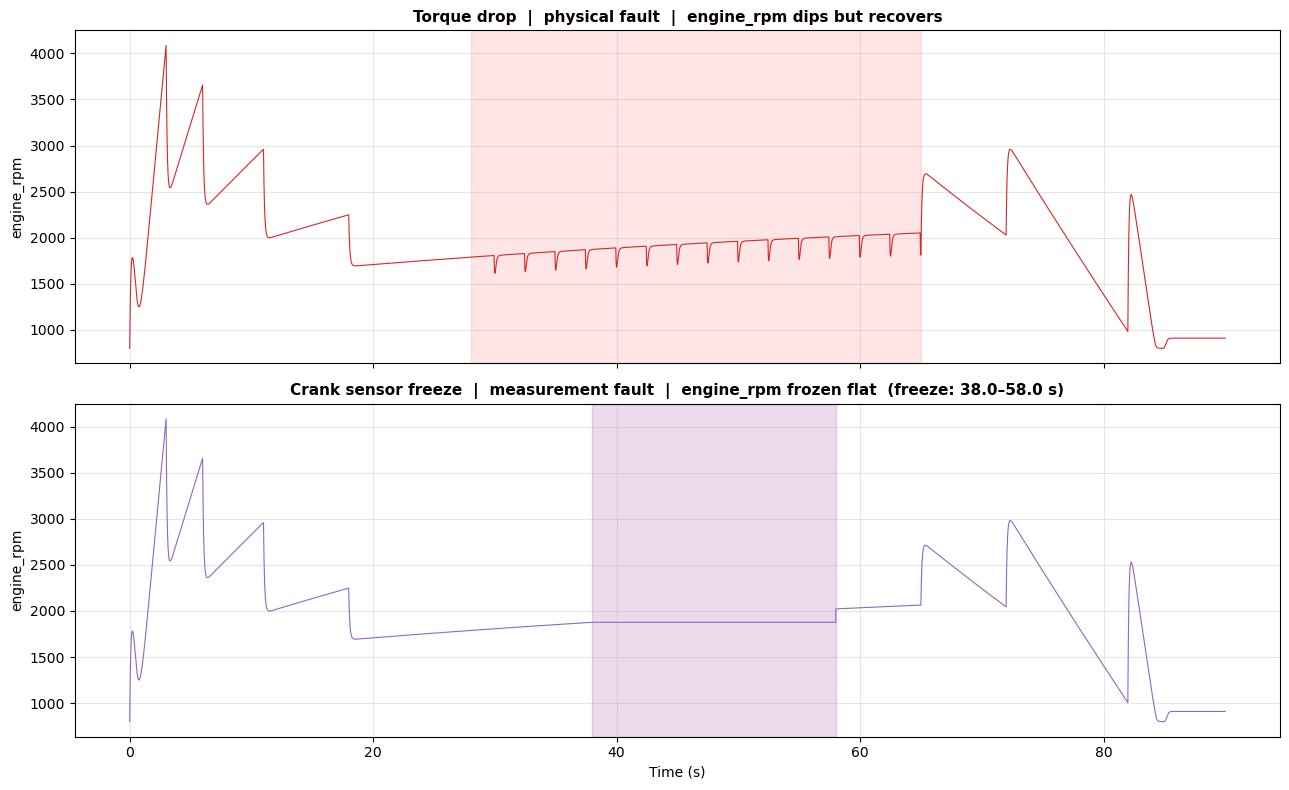

Key discriminator:
  - Torque drop: engine_rpm VARIES (dips and recovers) — the engine is really misbehaving
  - Crank sensor freeze: engine_rpm is FLAT — the engine is fine, only the sensor is broken

A model that correlates engine_rpm with throttle_position and longitudinal_acceleration
can tell them apart:
  - Torque drop: engine_rpm dips even when throttle is applied
  - Sensor freeze: engine_rpm is constant, but throttle and acceleration continue to vary


In [14]:
# Cell 10 — Compare the two fault signatures (with correct shading)
from src.config_loader import ConfigLoader
from src.signal_generator import Scenario

loader = ConfigLoader(PROJECT_ROOT / "config")

# --- Torque drop ---
scenario_td = Scenario.from_yaml(
    PROJECT_ROOT / "config" / "scenarios" / "highway_cruise_torque_drop.yaml",
    fault_registry=loader.load_fault_types(),
)
f_td = scenario_td.resolved_faults[0]

# --- Crank sensor freeze ---
scenario_cf = Scenario.from_yaml(
    PROJECT_ROOT / "config" / "scenarios" / "highway_cruise_crank_sensor_freeze.yaml",
    fault_registry=loader.load_fault_types(),
)
f_cf = scenario_cf.resolved_faults[0]
freeze_end = f_cf.onset_s + f_cf.params["freeze_duration_s"]

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Torque drop
sig_td = torque_drop["signals"]
axes[0].plot(sig_td["time_s"], sig_td["engine_rpm"], linewidth=0.8, color="tab:red")
axes[0].axvspan(f_td.onset_s, f_td.end_s, alpha=0.10, color="red")
axes[0].set_ylabel("engine_rpm")
axes[0].set_title(
    f"Torque drop  |  physical fault  |  engine_rpm dips but recovers",
    fontsize=11, fontweight="bold"
)
axes[0].grid(alpha=0.3)

# Crank sensor freeze — shade the actual freeze window
sig_cf = crank_freeze["signals"]
axes[1].plot(sig_cf["time_s"], sig_cf["engine_rpm"], linewidth=0.8, color="tab:purple")
axes[1].axvspan(f_cf.onset_s, freeze_end, alpha=0.15, color="purple")
axes[1].set_ylabel("engine_rpm")
axes[1].set_xlabel("Time (s)")
axes[1].set_title(
    f"Crank sensor freeze  |  measurement fault  |  engine_rpm frozen flat  "
    f"(freeze: {f_cf.onset_s:.1f}–{freeze_end:.1f} s)",
    fontsize=11, fontweight="bold"
)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Key discriminator:")
print("  - Torque drop: engine_rpm VARIES (dips and recovers) — the engine is really misbehaving")
print("  - Crank sensor freeze: engine_rpm is FLAT — the engine is fine, only the sensor is broken")
print()
print("A model that correlates engine_rpm with throttle_position and longitudinal_acceleration")
print("can tell them apart:")
print("  - Torque drop: engine_rpm dips even when throttle is applied")
print("  - Sensor freeze: engine_rpm is constant, but throttle and acceleration continue to vary")

In [12]:
# Summary
print("=" * 70)
print("PHASE B — CRANK FAULTS")
print("=" * 70)
print()
print("Two fault types were added:")
print()
print("1. crankshaft_torque_drop (mechanical, physics-layer)")
print("   - Intermittent brief losses of engine torque")
print("   - Observable: engine_rpm dips, longitudinal_acceleration dips,")
print("     vehicle_speed slightly reduced")
print(f"   - Fault window: {torque_drop['faults'].iloc[0]['onset_s']}–"
      f"{torque_drop['faults'].iloc[0]['end_s']} s")
print(f"   - Severity (drop_magnitude): {torque_drop['faults'].iloc[0]['severity']:.2f}")
print()
print("2. crank_sensor_failure (sensor, post-physics)")
print("   - Crank sensor stops updating; engine continues normally")
print("   - Observable: engine_rpm and crank_position freeze")
print("   - Cross-check: vehicle_speed, longitudinal_acceleration,")
print("     throttle_position continue normally")
print(f"   - Fault window: {crank_freeze['faults'].iloc[0]['onset_s']}–"
      f"{crank_freeze['faults'].iloc[0]['end_s']} s")
print(f"   - Severity (normalized freeze duration): "
      f"{crank_freeze['faults'].iloc[0]['severity']:.3f}")
print()
print("Discriminating pattern:")
print("  Physical faults (torque drop) affect motion through the physics cascade.")
print("  Measurement faults (sensor freeze) affect only the reported signal.")
print("  A model that learns the relationship between throttle, acceleration,")
print("  and RPM can distinguish between them.")

PHASE B — CRANK FAULTS

Two fault types were added:

1. crankshaft_torque_drop (mechanical, physics-layer)
   - Intermittent brief losses of engine torque
   - Observable: engine_rpm dips, longitudinal_acceleration dips,
     vehicle_speed slightly reduced
   - Fault window: 28.0–65.0 s
   - Severity (drop_magnitude): 0.70

2. crank_sensor_failure (sensor, post-physics)
   - Crank sensor stops updating; engine continues normally
   - Observable: engine_rpm and crank_position freeze
   - Cross-check: vehicle_speed, longitudinal_acceleration,
     throttle_position continue normally
   - Fault window: 38.0–65.0 s
   - Severity (normalized freeze duration): 0.333

Discriminating pattern:
  Physical faults (torque drop) affect motion through the physics cascade.
  Measurement faults (sensor freeze) affect only the reported signal.
  A model that learns the relationship between throttle, acceleration,
  and RPM can distinguish between them.
